# Sorting Comparison

The first experiment try to determine which local sorting strategy is the best (in terms of computational time) for the Parallel Sample Sort.\
The two sorting algorithms compared are **Quick Sort** and **Radix Sort**.\
Both implementations are parallelized at **OMP level**.

The **QS** implementation is recursive, and has two cutoff levels :

1. **Serial Cutoff** (at 25000 elements) : blocks the parallel recursion and let a serial implementation handles the rest
2. **Small Size Cutoff** (at 8 elements) : blocks the recursive implementation and let an Insertion Sort handles the rest

The **RS** implementation is iterative and based on a **Stable Counting Sort**.

Both the implementation takes inspiration by various **forums, online discussions and public github repositories**, at which in addiction there is a personal researcher based **also** on LLM.

The experiments is based solely at **OMP level**. This means that there is only **1 open MPI rank** running the entire code for all the various test cases, while the number of **OMP threads** increase exponentially, **from 1 up to 64**.

In addiction there is also a study about the time discrepancy between the two algorithms in case of **64 bit keys** and **32 bit keys**.

Here is reported the common configuration for all the experiments:

* **n_keys** : $5\times10^7$
* **n_ranks** : $1$
* **keys_distribution** : uniform

Experiments were executed on [**Orfeo, partition GENOA**](https://orfeo-doc.areasciencepark.it/HPC/computational-resources/).

The key metric here is **time_local_sort_seconds**.

In [1]:
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns

## Sorting Algorithm Comparison (threads wise)

In [2]:
results = pd.read_csv("../Parallel/results/sorting_comparison.csv")
results = results[
    ["n_bits", "n_threads", "local_sort_algorithm", "time_local_sort_seconds"]
]
results.head()

,n_bits,n_threads,local_sort_algorithm,time_local_sort_seconds
0,32,1,radix,0.331524
1,32,1,quick,3.393352
2,32,2,radix,0.183947
3,32,2,quick,1.785251
4,32,4,radix,0.091525


In [3]:
n_bits_value = 32 # select number of bit
plot_data = results[results["n_bits"] == n_bits_value] # select the data with that number of bit

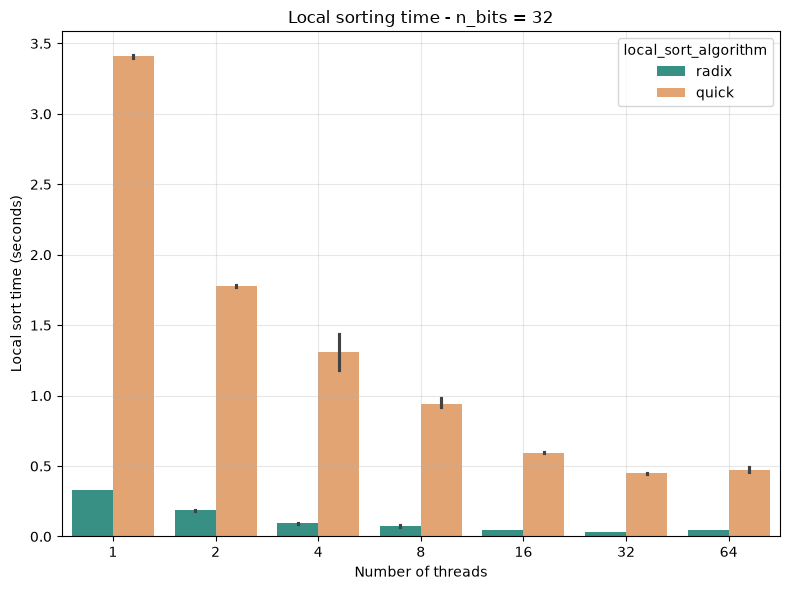

In [4]:
custom_palette = {
    "radix" : "#2A9D8F",
    "quick" : "#F4A261"
}

plt.figure(figsize=(8, 6))

sns.barplot(
    data=plot_data,
    x="n_threads",
    y="time_local_sort_seconds",
    hue="local_sort_algorithm",
    palette=custom_palette
)

plt.xlabel("Number of threads")
plt.ylabel("Local sort time (seconds)")
plt.title(f"Local sorting time - n_bits = {n_bits_value}")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Bit size comparison (threads wise)

In [5]:
results = pd.read_csv("../Parallel/results/sorting_comparison.csv")
results = results[
    ["n_bits", "n_threads", "local_sort_algorithm", "time_local_sort_seconds"]
]
algorithm = "quick"
plot_data = results[
    results["local_sort_algorithm"] == algorithm
]

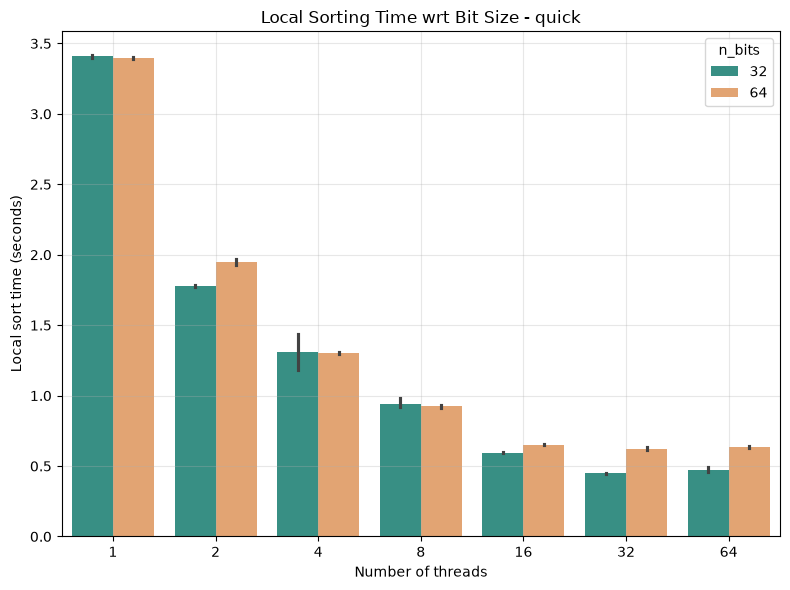

In [6]:
custom_palette = {
    32 : "#2A9D8F",
    64 : "#F4A261"
}

plt.figure(figsize=(8, 6))

sns.barplot(
    data=plot_data,
    x="n_threads",
    y="time_local_sort_seconds",
    hue="n_bits",
    palette=custom_palette
)

plt.xlabel("Number of threads")
plt.ylabel("Local sort time (seconds)")
plt.title(f"Local Sorting Time wrt Bit Size - {algorithm}")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()